# Earthquake Analysis Dashboard

### Department
Department of Earth Sciences

### Domain
GIS (Geographic Information Systems)

### Objective
This project fetches the latest global earthquake data from the USGS, performs basic statistical analysis, and visualizes earthquake locations on an interactive world map using Python.

## 1. Install Required Libraries

This step installs the Python libraries required for interactive mapping and data analysis.

In [2]:
!pip -q install folium

## 2. Import Required Libraries

The required Python libraries are imported for data processing, visualization, and interactive map generation.

In [3]:
import pandas as pd
import folium
from google.colab import files

## 3. Download Live Earthquake Data

The latest global earthquake data is fetched directly from the USGS Earthquake Catalog in CSV format.

In [4]:
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"

df = pd.read_csv(url)

df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-07-06T15:05:45.150Z,35.498333,-118.398667,4.26,1.10,ml,27.0,80.0,0.175200,0.12,...,2026-07-06T15:09:05.974Z,"13 km SE of Bodfish, CA",earthquake,0.17,0.56,0.108875,14.0,automatic,ci,ci
1,2026-07-06T14:48:21.500Z,38.813332,-122.784668,1.50,1.14,md,12.0,71.0,0.009885,0.02,...,2026-07-06T15:07:21.092Z,"5 km NNW of The Geysers, CA",earthquake,0.27,0.57,0.220000,14.0,automatic,nc,nc
2,2026-07-06T14:36:21.173Z,28.301000,-98.495000,0.00,1.80,ml,5.0,166.0,0.400000,0.20,...,2026-07-06T14:39:11.626Z,"18 km SSE of Tilden, Texas",earthquake,0.00,NaN,0.300000,5.0,automatic,tx,tx
3,2026-07-06T14:31:44.830Z,33.255667,-116.116500,7.08,0.71,ml,36.0,56.0,0.131200,0.20,...,2026-07-06T14:35:06.960Z,"13 km N of Ocotillo Wells, CA",earthquake,0.21,0.85,0.121157,11.0,automatic,ci,ci
4,2026-07-06T14:20:10.200Z,33.900500,-116.166500,5.09,0.72,ml,29.0,66.0,0.025540,0.16,...,2026-07-06T14:23:31.566Z,"21 km NNE of Indio, CA",earthquake,0.24,0.48,0.096481,15.0,automatic,ci,ci


## 4. Interactive Earthquake Map

An interactive map is generated using the Folium library. Earthquakes are represented by colored markers based on their magnitude.

In [6]:
# Create a world map
m = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB positron")

# Function to assign colors based on magnitude
def get_color(mag):
    if mag >= 6:
        return "red"
    elif mag >= 5:
        return "orange"
    elif mag >= 4:
        return "blue"
    else:
        return "green"

# Plot only the first 1000 earthquakes
# (keeps the map responsive)
for _, row in df.head(1000).iterrows():

    popup = f"""
    <b>Place:</b> {row['place']}<br>
    <b>Magnitude:</b> {row['mag']}<br>
    <b>Depth:</b> {row['depth']} km<br>
    <b>Time:</b> {row['time']}
    """

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=max(row['mag']*2, 2),
        color=get_color(row['mag']),
        fill=True,
        fill_color=get_color(row['mag']),
        fill_opacity=0.7,
        popup=popup
    ).add_to(m)

m

## 5. Statistical Analysis

This section computes basic statistics such as:
- Total earthquakes
- Average magnitude
- Strongest earthquake
- Deepest earthquake

In [8]:
# Basic Statistics

total_earthquakes = len(df)
average_magnitude = df["mag"].mean()
maximum_magnitude = df["mag"].max()
deepest_earthquake = df["depth"].max()

strongest = df.loc[df["mag"].idxmax()]
deepest = df.loc[df["depth"].idxmax()]

print("="*50)
print("EARTHQUAKE ANALYSIS SUMMARY")
print("="*50)

print(f"Total Earthquakes      : {total_earthquakes}")
print(f"Average Magnitude      : {average_magnitude:.2f}")
print(f"Strongest Earthquake   : {maximum_magnitude}")
print(f"Occurred At            : {strongest['place']}")
print(f"Deepest Earthquake     : {deepest_earthquake} km")
print(f"Occurred At            : {deepest['place']}")

EARTHQUAKE ANALYSIS SUMMARY
Total Earthquakes      : 10529
Average Magnitude      : 1.67
Strongest Earthquake   : 7.8
Occurred At            : 25 km SW of Kablalan, Philippines
Deepest Earthquake     : 685.692 km
Occurred At            : 274 km SE of Levuka, Fiji


## 6. Magnitude Distribution

The histogram illustrates the distribution of earthquake magnitudes observed during the selected time period.

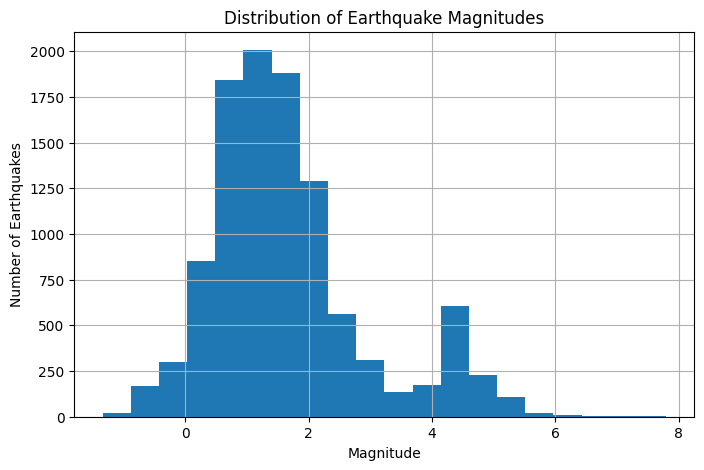

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["mag"], bins=20)

plt.title("Distribution of Earthquake Magnitudes")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")

plt.grid(True)

plt.show()

## 7. Top 10 Strongest Earthquakes

This table lists the strongest earthquakes recorded in the dataset along with their location, depth, and occurrence time.

In [10]:
top10 = df.sort_values("mag", ascending=False)[["place","mag","depth","time"]]

top10.head(10)

,place,mag,depth,time
10000,"25 km SW of Kablalan, Philippines",7.8,56.991,2026-06-07T23:37:41.970Z
3273,"20 km ESE of Yumare, Venezuela",7.5,10.000,2026-06-24T22:05:11.743Z
3274,"21 km ENE of San Felipe, Venezuela",7.2,27.588,2026-06-24T22:04:34.363Z
3269,"33 km ENE of Noda, Japan",6.9,34.000,2026-06-24T22:30:12.989Z
6697,"43 km ESE of Palu, Indonesia",6.7,10.000,2026-06-16T03:27:44.418Z
5963,central Mid-Atlantic Ridge,6.6,10.000,2026-06-17T18:56:58.028Z
5426,"133 km ESE of Petropavlovsk-Kamchatsky, Russia",6.6,10.000,2026-06-19T06:52:31.597Z
9974,"18 km SW of Balangonan, Philippines",6.5,75.065,2026-06-08T00:55:12.546Z
2781,"34 km WSW of Sarangani, Philippines",6.5,42.000,2026-06-26T11:34:41.498Z
6596,"262 km SSE of Dunhuang, China",6.3,10.000,2026-06-16T09:06:55.517Z


# Conclusion

This project demonstrates how publicly available seismic data can be automatically collected, analyzed, and visualized using Python. Such dashboards can assist researchers, students, and decision-makers in understanding global earthquake activity.